In [9]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd

In [7]:
insurenace_data=pd.read_csv("insurance.csv")

#interaction features
X=insurenace_data.drop(columns=["charges"])
y=insurenace_data["charges"]
X=pd.get_dummies(X,columns=["region"],drop_first=False,dtype=int)
X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X["age_smoker"]=X["age"]*X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


MSE for apha=0.001: 20922596.52800621
MSE for apha=0.1: 20921899.287567742
MSE for apha=1: 20915761.34772445
MSE for apha=2: 20909904.88284825
MSE for apha=5: 20894930.88738715
MSE for apha=10: 20879460.429074317
MSE for apha=20: 20885116.38537385
MSE for apha=30: 20939554.097556505
MSE for apha=40: 21030365.00375736
MSE for apha=50: 21137371.396251045
MSE for apha=100: 22325946.521791253


<Axes: >

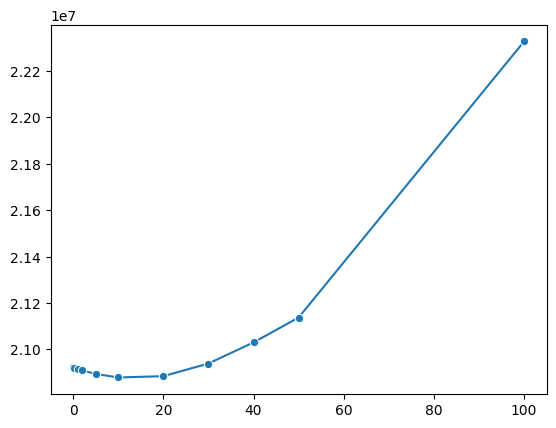

In [21]:
import seaborn as sns
alpha=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for a in alpha:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)

    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    print(f"MSE for apha={a}:",mse)
    mses.append(mse)
sns.lineplot(x=alpha,y=mses,marker="o")